In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astropy.io import fits

In [2]:
FUGIN_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/FGN_01100+0000_2x2_12CO_v1.00_cube.fits"
bubble_rabge_storage = np.load("bubble_range_storage.npz")

In [18]:
hdu = fits.open(FUGIN_path)[0]
header = hdu.header
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  848                                                  
NAXIS2  =                  848                                                  
NAXIS3  =                  462                                                  
EXTEND  =                    T                                                  
BSCALE  =                  1.0                                                  
BZERO   =                  0.0                                                  
BMAJ    = 0.005611111111111111                                                  
BMIN    = 0.005611111111111111                                                  
BPA     =                  0.0                                                  
BTYPE   = 'Intensity'       

In [17]:
loaded_list = [bubble_rabge_storage[key] for key in bubble_rabge_storage.files]
print("バブル数: ", len(loaded_list))

バブル数:  1924


In [5]:
loaded_sum_list = [len(array) for array in loaded_list]
velocity_sum_list = [val*header["CDELT3"]/1000 for val in loaded_sum_list]

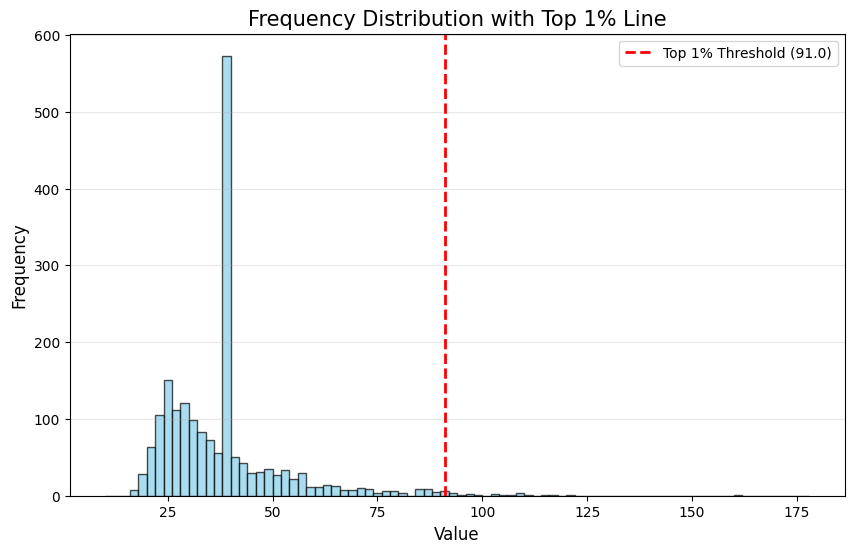

In [10]:
# --- 1. 統計量の計算 ---
# 上位1%の境界値（99パーセンタイル）を計算
# maxから数えて1%なので、全体の下から99%の位置
threshold_1percent = np.percentile(loaded_sum_list, 99)

# --- 3. プロットの作成 ---
plt.figure(figsize=(10, 6))
# ヒストグラムの描画
bins = range(min(loaded_sum_list)//10*10, (max(loaded_sum_list)//10+2)*10, 2)
n, bins_hist, patches = plt.hist(loaded_sum_list, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)

# 上位1%ラインの描画 (垂直線)
plt.axvline(threshold_1percent, color='red', linestyle='--', linewidth=2, 
            label=f'Top 1% Threshold ({threshold_1percent:.1f})')

# 装飾
plt.title('Frequency Distribution with Top 1% Line', fontsize=15)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig("bubble_Histogram.svg")
plt.show()

In [26]:
s = pd.Series(loaded_sum_list)

bins = range(int(min(loaded_sum_list)//10*10), int((max(loaded_sum_list)//10+2)*10), 10)
frequency_table = pd.cut(s, bins=bins).value_counts().sort_index().reset_index()
frequency_table.columns = ['Range', 'Frequency']
frequency_table['Percentage (%)'] = (frequency_table['Frequency'] / len(loaded_sum_list) * 100).round(1)

print(frequency_table)
print(f"\n上位1%の境界値: {threshold_1percent:.2f}")

         Range  Frequency  Percentage (%)
0     (10, 20]         36             1.9
1     (20, 30]        552            28.7
2     (30, 40]        883            45.9
3     (40, 50]        188             9.8
4     (50, 60]        124             6.4
5     (60, 70]         54             2.8
6     (70, 80]         35             1.8
7     (80, 90]         27             1.4
8    (90, 100]         13             0.7
9   (100, 110]          7             0.4
10  (110, 120]          3             0.2
11  (120, 130]          1             0.1
12  (130, 140]          0             0.0
13  (140, 150]          0             0.0
14  (150, 160]          0             0.0
15  (160, 170]          1             0.1

上位1%の境界値: 91.00


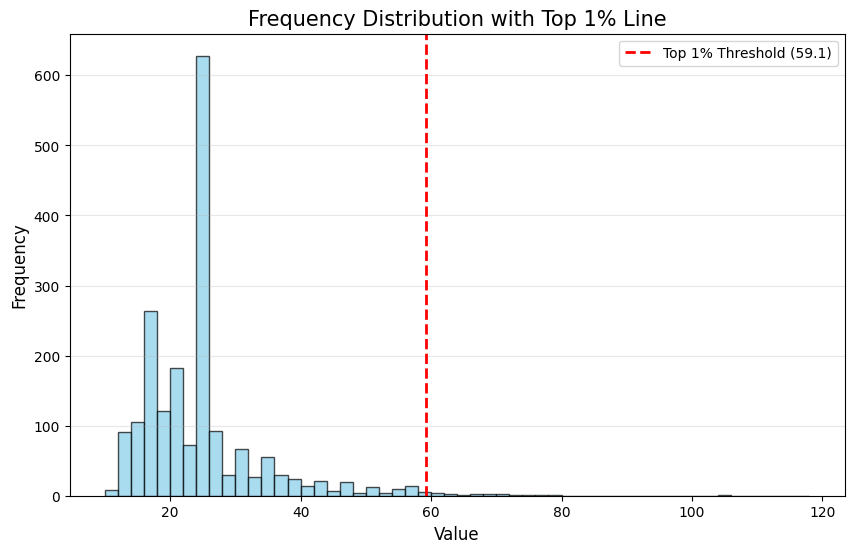

In [16]:
# --- 1. 統計量の計算 ---
# 上位1%の境界値（99パーセンタイル）を計算
# maxから数えて1%なので、全体の下から99%の位置
threshold_1percent = np.percentile(velocity_sum_list, 99)

# --- 3. プロットの作成 ---
plt.figure(figsize=(10, 6))
# ヒストグラムの描画
bins = range(int(min(velocity_sum_list))//10*10, int((max(velocity_sum_list))//10+2)*10, 2)
n, bins_hist, patches = plt.hist(velocity_sum_list, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)

# 上位1%ラインの描画 (垂直線)
plt.axvline(threshold_1percent, color='red', linestyle='--', linewidth=2, 
            label=f'Top 1% Threshold ({threshold_1percent:.1f})')

# 装飾
plt.title('Frequency Distribution with Top 1% Line', fontsize=15)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig("bubble_Histogram_velocity_ver.svg")
plt.show()

In [15]:
s = pd.Series(velocity_sum_list)

bins = range(int(min(velocity_sum_list)//10*10), int((max(velocity_sum_list)//10+2)*10), 10)
frequency_table = pd.cut(s, bins=bins).value_counts().sort_index().reset_index()
frequency_table.columns = ['Range', 'Frequency']
frequency_table['Percentage (%)'] = (frequency_table['Frequency'] / len(loaded_sum_list) * 100).round(1)

print(frequency_table)
print(f"\n上位1%の境界値: {threshold_1percent:.2f}")

        Range  Frequency  Percentage (%)
0    (10, 20]        588            30.6
1    (20, 30]       1005            52.2
2    (30, 40]        202            10.5
3    (40, 50]         65             3.4
4    (50, 60]         45             2.3
5    (60, 70]         11             0.6
6    (70, 80]          7             0.4
7    (80, 90]          0             0.0
8   (90, 100]          0             0.0
9  (100, 110]          1             0.1

上位1%の境界値: 59.15
